# EDA: Counterfeit Detection on Ozon Marketplace
## Authors: Соня (базовый EDA, Part 1), Альбина (углублённый EDA, Part 2)
## Структура: Part 1 — базовый анализ | Part 2 — углублённый анализ | Part 3 — выводы

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "wordcloud", "-q"])
    from wordcloud import WordCloud

In [2]:
# --- Auto-detect environment: Colab or local ---
try:
    from google.colab import drive  # noqa: F401
    drive.mount('/content/drive')
    DATA_DIR = Path('/content')
    IS_COLAB = True
except ImportError:
    DATA_DIR = Path(os.environ.get('OZON_DATA_DIR', '/Users/sofya/Desktop/ВКР /data'))
    IS_COLAB = False

assert DATA_DIR.exists(), f'DATA_DIR не найден: {DATA_DIR}'

# --- Pick filename (try both: with and without "c" typo) ---
def _pick(suffix):
    for name in (f'ml_ozon_counterfeit_{suffix}.csv', f'ml_ozon_ounterfeit_{suffix}.csv'):
        if (DATA_DIR / name).exists():
            return DATA_DIR / name
    raise FileNotFoundError(f'{suffix} CSV not found in {DATA_DIR}')

train_df = pd.read_csv(_pick('train'), encoding='utf-8')
test_df  = pd.read_csv(_pick('test'),  encoding='utf-8')

print('ENV:', 'Colab' if IS_COLAB else 'Local')
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
assert train_df.shape == (197198, 45), f'Unexpected train shape: {train_df.shape}'
assert test_df.shape == (22760, 44), f'Unexpected test shape: {test_df.shape}'
print('Shape check passed!')

ENV: Local
Train shape: (197198, 45)
Test shape: (22760, 44)
Shape check passed!


## Part 1: Базовый EDA

### 1.1 Data Overview

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197198 entries, 0 to 197197
Data columns (total 45 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            197198 non-null  int64  
 1   resolution                    197198 non-null  int64  
 2   brand_name                    116667 non-null  str    
 3   description                   171138 non-null  str    
 4   name_rus                      197198 non-null  str    
 5   CommercialTypeName4           197198 non-null  str    
 6   rating_1_count                47193 non-null   float64
 7   rating_2_count                47193 non-null   float64
 8   rating_3_count                47193 non-null   float64
 9   rating_4_count                47193 non-null   float64
 10  rating_5_count                47193 non-null   float64
 11  comments_published_count      47193 non-null   float64
 12  photos_published_count        47193 non-null   float64


- **Тренировочные данные**: 197,198 наблюдений, 45 признаков

- **Тестовые данные**: 22,760 наблюдений, 44 признака

**Ключевые группы признаков:**

- Идентификаторы: `id`, `ItemID`, `SellerID`

- Целевая переменная: `resolution`

- Временные признаки: `item_time_alive`, `seller_time_alive`

- Рейтинги и отзывы: `rating_X_count`, `comments_published_count`

- Продажи и возвраты: `item_count_salesX`, `item_count_returnsX`

- Финансовые метрики: `GmvTotalX`, `ExemplarReturnedValueTotalX`

- Текстовые данные: `brand_name`, `description`, `name_rus`

### 1.2 Распределение целевой переменной

In [4]:
target_col = 'resolution'
display(train_df[target_col].value_counts().sort_index())
display(train_df[target_col].value_counts(normalize=True))

resolution
0    184146
1     13052
Name: count, dtype: int64

resolution
0    0.933813
1    0.066187
Name: proportion, dtype: float64

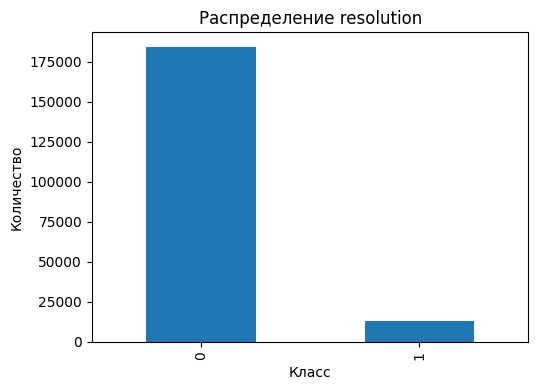

In [5]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
train_df[target_col].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение resolution')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

- **Класс 0**: 93.4% наблюдений (183,949) - "нормальные" товары

- **Класс 1**: 6.6% наблюдений (13,049) - "проблемные" товары

Что это значит для нас

- Сильный дисбаланс классов
- Модель, которая будет говорить, что все нормально, будет иметь accuracy 93% -> нельзя выбирать эту метрику

### 1.3 Пропущенные значения

In [6]:
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

missing_df = pd.DataFrame({
    'train_missing': missing_train,
    'train_%': (missing_train / len(train_df) * 100).round(1),
    'test_missing': missing_test,
    'test_%': (missing_test / len(test_df) * 100).round(1)
})

# Сортируем по проценту пропусков в train
missing_df = missing_df.sort_values('train_%', ascending=False)

In [7]:
missing_df[missing_df['train_missing'] > 0].head(15)

,train_missing,train_%,test_missing,test_%
comments_published_count,150005,76.1,21053.0,92.5
photos_published_count,150005,76.1,21053.0,92.5
rating_5_count,150005,76.1,21053.0,92.5
rating_4_count,150005,76.1,21053.0,92.5
rating_3_count,150005,76.1,21053.0,92.5
rating_2_count,150005,76.1,21053.0,92.5
rating_1_count,150005,76.1,21053.0,92.5
videos_published_count,150005,76.1,21053.0,92.5
brand_name,80531,40.8,5832.0,25.6
description,26060,13.2,2224.0,9.8


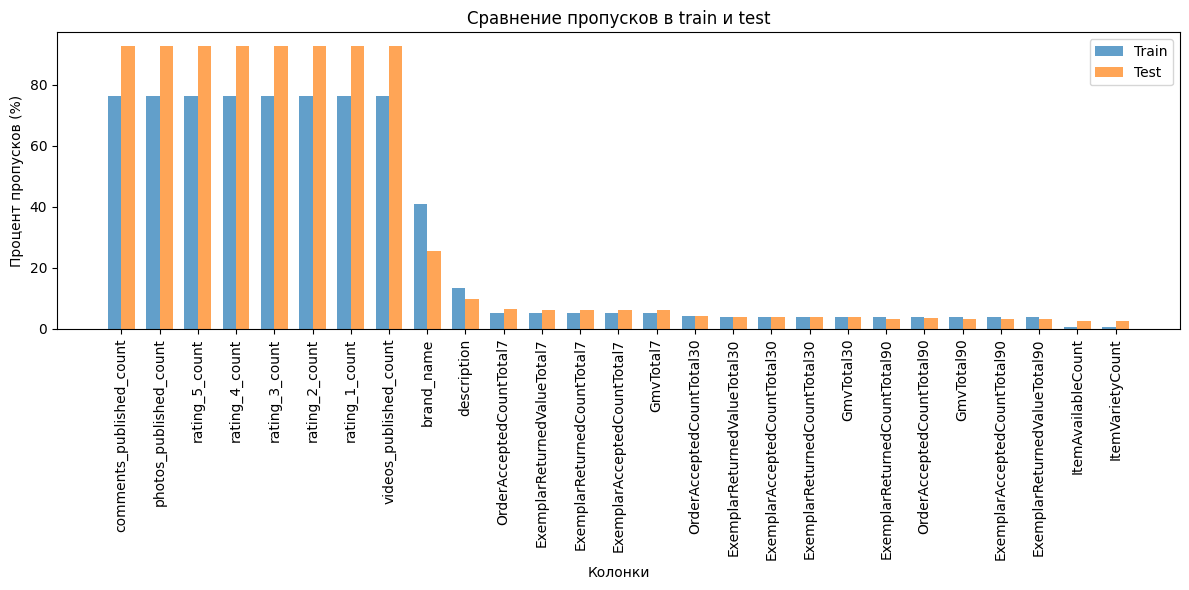

In [8]:
plt.figure(figsize=(12, 6))

missing_plot_df = missing_df[missing_df['train_%'] > 0]

x = range(len(missing_plot_df))
width = 0.35

plt.bar([i - width/2 for i in x], missing_plot_df['train_%'], width, label='Train', alpha=0.7)
plt.bar([i + width/2 for i in x], missing_plot_df['test_%'], width, label='Test', alpha=0.7)

plt.xlabel('Колонки')
plt.ylabel('Процент пропусков (%)')
plt.title('Сравнение пропусков в train и test')
plt.xticks(x, missing_plot_df.index, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Какие признаки имеют >50% пропусков?
high_missing = missing_df[missing_df['train_%'] > 50].index.tolist()
high_missing

['comments_published_count',
 'photos_published_count',
 'rating_5_count',
 'rating_4_count',
 'rating_3_count',
 'rating_2_count',
 'rating_1_count',
 'videos_published_count']

### 1.4 Дубликаты и leakage check

In [10]:
# 1. Дубликаты по всей строке
total_dup = train_df.duplicated().sum()
print(f"Полных дубликатов строк в train: {total_dup} ({total_dup/len(train_df)*100:.3f}%)")

# 2. Дубликаты по ItemID (должно быть 0, ItemID — уникальный идентификатор)
item_dup = train_df.duplicated(subset=['ItemID']).sum()
print(f"Дубликатов по ItemID в train: {item_dup}")

# 3. Дубликаты по содержательным признакам
content_cols = ['name_rus', 'description', 'brand_name', 'PriceDiscounted', 'SellerID']
content_cols = [c for c in content_cols if c in train_df.columns]
content_dup = train_df.duplicated(subset=content_cols).sum()
print(
    f"Дубликатов по (name+description+brand+price+seller): {content_dup} "
    f"({content_dup/len(train_df)*100:.2f}%)"
)

# 4. Пересечение ItemID между train и test — критический тест на leakage
if 'ItemID' in train_df.columns and 'ItemID' in test_df.columns:
    overlap = set(train_df['ItemID']) & set(test_df['ItemID'])
    print(f"\n=== LEAKAGE CHECK ===")
    print(f"ItemID пересекается между train и test: {len(overlap)}")
    assert len(overlap) == 0, "КРИТИЧЕСКАЯ ОШИБКА: ItemID утечка между train и test!"
    print("✓ Leakage не обнаружен")

Полных дубликатов строк в train: 0 (0.000%)
Дубликатов по ItemID в train: 0
Дубликатов по (name+description+brand+price+seller): 0 (0.00%)

=== LEAKAGE CHECK ===
ItemID пересекается между train и test: 0
✓ Leakage не обнаружен


Результаты проверки:
- Полных дубликатов в train: `0`
- Дубликатов по `ItemID`: `0`
- Дубликатов по содержательным признакам: `0`
- Пересечение `ItemID` train/test: `0`

Вывод: на текущем шаге дубликаты и leakage по `ItemID` не обнаружены. Это снижает риск того, что модель случайно видит один и тот же товар одновременно в `train` и `test`.

### 1.5 Анализ брендов

                items_count  problem_rate
brand_name                               
Sony                   3053      0.196528
UNKNOWN_BRAND         80531      0.097664
Xiaomi                 1970      0.034010
MyPads                 2001      0.022989
ТехМаркет              1262      0.018225
GP                      932      0.012876
OEM                    4275      0.009123
Promise Mobile         1025      0.007805
Levsha kaluga          3009      0.004985
HUAYU                  2754      0.003994


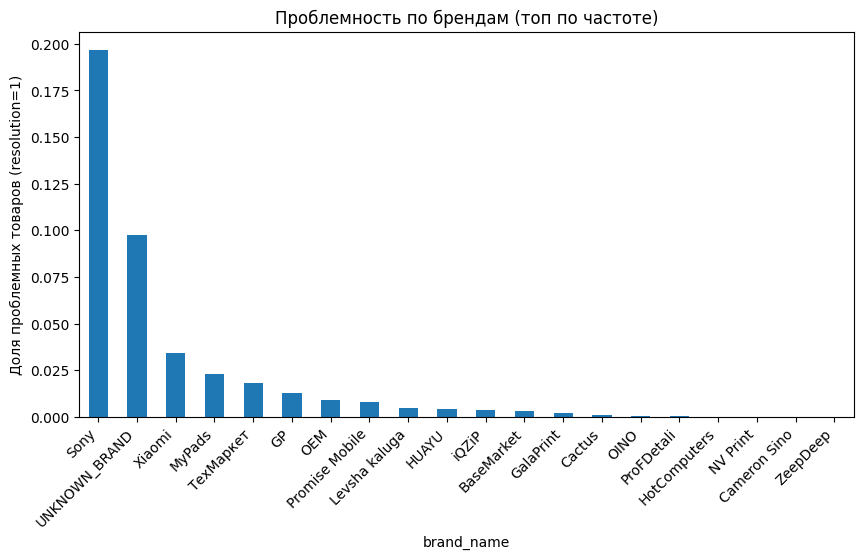

In [11]:
df = train_df.copy()
df["brand_name"] = df["brand_name"].fillna("UNKNOWN_BRAND")
top_brands = df["brand_name"].value_counts().head(20).index

df_top = df[df["brand_name"].isin(top_brands)]
brand_stats = (
    df_top
    .groupby("brand_name")
    .agg(
        items_count=("resolution", "size"),
        problem_rate=("resolution", "mean")
    )
    .sort_values("problem_rate", ascending=False)
)

print(brand_stats.head(10))

plt.figure(figsize=(10,5))
brand_stats["problem_rate"].plot(kind="bar")
plt.ylabel("Доля проблемных товаров (resolution=1)")
plt.title("Проблемность по брендам (топ по частоте)")
plt.xticks(rotation=45, ha="right")
plt.show()


Среди товаров без бренда и товаров Sony больше всего фейковых товаров.

### 1.6 Распределения числовых признаков


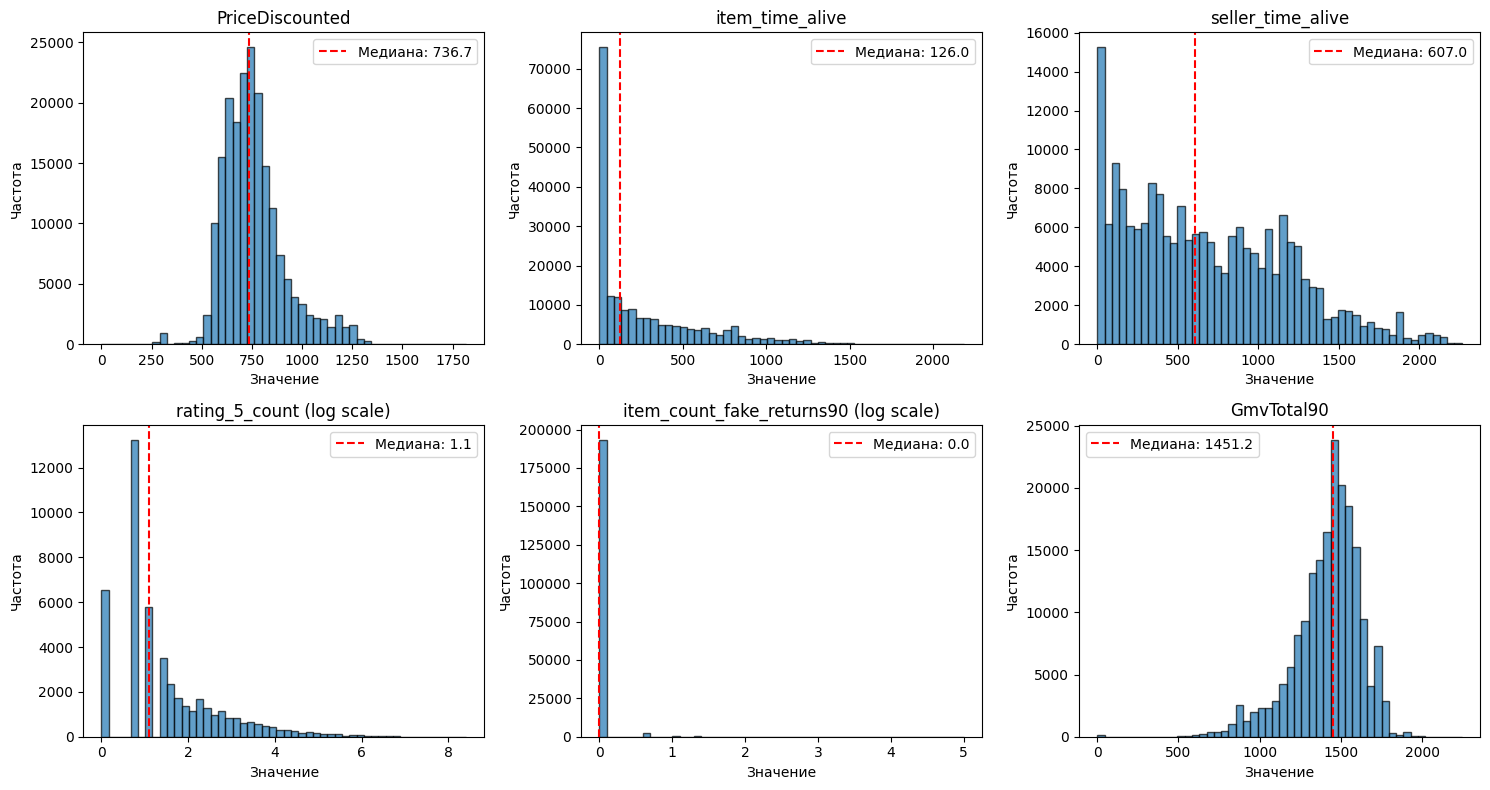

In [12]:
# Анализ распределения ключевых числовых признаков
key_features = ['PriceDiscounted', 'item_time_alive', 'seller_time_alive',
                'rating_5_count', 'item_count_fake_returns90', 'GmvTotal90']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if col in train_df.columns:
        data = train_df[col].dropna()

        # Для сильно скошенных распределений используем логарифм
        if data.skew() > 5:
            data_to_plot = np.log1p(data)
            title_suffix = ' (log scale)'
        else:
            data_to_plot = data
            title_suffix = ''

        axes[i].hist(data_to_plot, bins=50, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{col}{title_suffix}')
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Частота')

        # Добавим вертикальную линию на медиану
        median_val = np.median(data_to_plot)
        axes[i].axvline(median_val, color='red', linestyle='--',
                       label=f'Медиана: {median_val:.1f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

In [13]:
# Статистика по ключевым признакам
stats_df = train_df[key_features].describe().T
stats_df['skew'] = train_df[key_features].skew()
stats_df['zeros_%'] = (train_df[key_features] == 0).mean() * 100

display(stats_df[['count', 'mean', 'std', 'min', '50%', 'max', 'skew', 'zeros_%']])

,count,mean,std,min,50%,max,skew,zeros_%
PriceDiscounted,197198.0,758.971530,155.940582,0.0,736.695421,1816.563093,0.970004,0.000507
item_time_alive,197198.0,274.667238,339.069596,0.0,126.000000,2185.000000,1.445656,0.698283
seller_time_alive,197198.0,684.575827,498.399100,1.0,607.000000,2265.000000,0.562213,0.000000
rating_5_count,47193.0,13.446274,63.103940,0.0,2.000000,4465.000000,26.714114,3.313421
item_count_fake_returns90,197198.0,0.062607,1.199047,0.0,0.000000,148.000000,58.870467,98.073003
GmvTotal90,189791.0,1416.615012,206.565858,0.0,1451.158907,2243.498157,-1.064402,0.055781


**PriceDiscounted (Цена)**:

 - Средняя цена: ~759

- Медиана: ~737 (распределение немного правоскошенное)

- Минимальная цена 0 - возможно, ошибка или бесплатные товары

- Практически нет нулевых цен (0.05%)

**item_time_alive (Время жизни товара)**:

- Среднее: 274 дня, Медиана: 126 дней (сильно правоскошенное)

- 0.7% товаров имеют 0 дней жизни (новые?)

- Максимум: 2185 дней (~6 лет)

**seller_time_alive (Время жизни продавца)**:

- Более равномерное распределение

- Среднее: 684 дня, Медиана: 607 дней

- Минимум 1 день, максимум 2265 дней (~6.2 года)

**rating_5_count (5-звездочные оценки)**:

- Сильно скошенное распределение: 79.4% нулевых значений!

- Среднее: 3.2, но медиана: 0

- Максимум 4465 - выбросы

**item_count_fake_returns90 (Фейковые возвраты за 90 дней)**:

- 98.1% нулевых значений - большинство товаров без фейковых возвратов

- Среднее: 0.06, медиана: 0
При наличии - может быть много (до 148)

**GmvTotal90 (Выручка за 90 дней)**:

- GmvTotal90 имеет сильную правостороннюю асимметрию (long tail), типичную для sales-данных.

- Среднее: 1416, медиана: 1451

- 0.06% нулевых значений

**Ключевые инсайты:**

- Большинство признаков имеют много нулей (спарсивость данных)

- Сильные выбросы в рейтингах и возвратах

- Время жизни товара сильно варьируется


### 1.7 Числовые признаки по классам


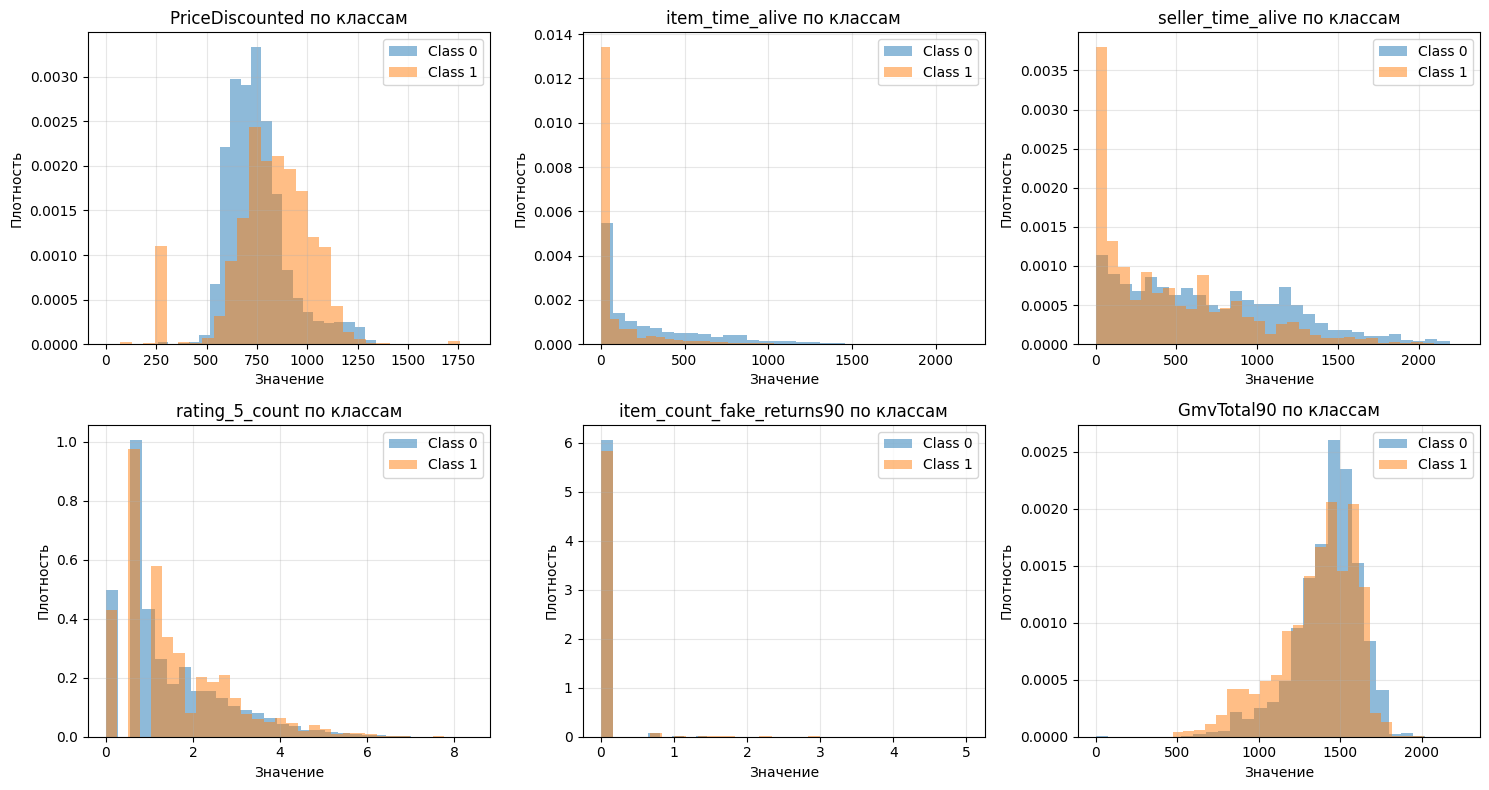

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]

    # Для каждого класса целевой переменной
    for target_val in [0, 1]:
        if col in train_df.columns:
            data = train_df[train_df['resolution'] == target_val][col].dropna()

            if len(data) > 0:
                # Логарифмируем при необходимости
                if data.skew() > 5:
                    data_to_plot = np.log1p(data)
                else:
                    data_to_plot = data

                ax.hist(data_to_plot, bins=30, alpha=0.5,
                       label=f'Class {target_val}', density=True)

    ax.set_title(f'{col} по классам')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Статистика по классам для ключевых признаков
stats_by_class = {}
for col in key_features:
    if col in train_df.columns:
        stats = train_df.groupby('resolution')[col].agg(['mean', 'median', 'std', 'count'])
        stats_by_class[col] = stats

# Посмотрим различия
for col, stats in stats_by_class.items():
    print(f"\n{col}:")
    print(stats)

    # Разница в средних между классами
    if 0 in stats.index and 1 in stats.index:
        mean_diff = stats.loc[1, 'mean'] - stats.loc[0, 'mean']
        print(f"  Разница средних (Class1 - Class0): {mean_diff:.3f}")


PriceDiscounted:
                  mean      median         std   count
resolution                                            
0           754.667684  732.939783  150.658899  184146
1           819.692959  833.109524  207.892311   13052
  Разница средних (Class1 - Class0): 65.025

item_time_alive:
                  mean  median         std   count
resolution                                        
0           287.633905   146.0  343.412582  184146
1            91.725176     9.0  193.166153   13052
  Разница средних (Class1 - Class0): -195.909

seller_time_alive:
                  mean  median        std   count
resolution                                       
0           701.869392   630.0  498.14668  184146
1           440.587113   318.0  433.83770   13052
  Разница средних (Class1 - Class0): -261.282

rating_5_count:
                 mean  median        std  count
resolution                                     
0           13.331186     2.0  62.577128  45168
1           16.013333  

**Сравнение распределений по классам**

**1. PriceDiscounted:**

- Проблемные товары (class 1) дороже: 819 vs 754 (разница +65)

- У проблемных товаров больше разброс цен (std 208 vs 151)

**2. item_time_alive:**

- Проблемные товары моложе: 92 дня vs 288 дней (разница -196)

- Медиана: 9 дней vs 146 дней!

**Ключевой инсайт:** Новые товары чаще проблемные

**3. seller_time_alive:**

- Проблемные продавцы моложе: 441 день vs 702 дня (разница -261)

- Медиана: 318 дней vs 630 дней

**Ключевой инсайт:** Новые продавцы чаще продают проблемные товары

**4. rating_5_count:**

- Незначительная разница (3.27 vs 2.48)

В обоих классах медиана = 0 (у большинства нет 5-звездочных оценок)

**5. item_count_fake_returns90:**

- Проблемные товары имеют больше фейковых возвратов: 0.20 vs 0.05

- Но медиана в обоих классах = 0 (у большинства нет возвратов)

- Разница в 4 раза!

**6. GmvTotal90:**

- Проблемные товары имеют меньшую выручку: 1351 vs 1420

- Меньше активных продаж у проблемных товаров

**Выводы:**

- Новые = риск: Новые товары и новые продавцы → выше риск проблем

- Дороже = риск: Проблемные товары в среднем дороже

- Возвраты = индикатор: Фейковые возвраты в 4 раза чаще у проблемных товаров

- Продажи ниже: У проблемных товаров меньше выручка

### 1.8 Категориальные признаки


**Различение типов:**

- **Категориальные признаки** (небольшое число уникальных значений): `CommercialTypeName4`.
- **Текстовые признаки** (свободный текст / много уникальных значений): `name_rus`, `description`, `brand_name`.

Ниже разбираем категориальные признаки и бинарный сигнал «есть ли описание / бренд».


In [16]:
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Категориальных признаков: {len(cat_cols)}")
print(cat_cols)

Категориальных признаков: 4
['brand_name', 'description', 'name_rus', 'CommercialTypeName4']


/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_88047/726087123.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()


In [17]:
# Детальная статистика для каждого признака
for col in cat_cols:

    print(f"Уникальных значений: {train_df[col].nunique()}")
    print(f"Пропусков: {train_df[col].isnull().sum()} ({train_df[col].isnull().mean()*100:.1f}%)")

    # Создаем временный признак для анализа
    if col == 'description':
        temp_series = train_df[col].notnull()
        temp_series.name = 'has_description'
    elif train_df[col].nunique() > 50:
        # Берем только топ-20 значений по частоте
        top_values = train_df[col].value_counts().head(20).index
        temp_series = train_df[col].where(train_df[col].isin(top_values), 'other')
    else:
        temp_series = train_df[col]

    # Статистика по целевой переменной
    stats = train_df.groupby(temp_series)['resolution'].agg(['mean', 'count', 'sum'])
    stats = stats.sort_values('mean', ascending=False)

    print(f"\nДоля проблемных товаров (top-10):")
    display(stats.head(10))

    # Ключевые инсайты
    if len(stats) > 1:
        max_val = stats.index[0]
        min_val = stats.index[-1]
        max_rate = stats.loc[max_val, 'mean']
        min_rate = stats.loc[min_val, 'mean']

        print(f"- Макс. доля проблемных: {max_val} = {max_rate:.3f}")
        print(f"- Мин. доля проблемных: {min_val} = {min_rate:.3f}")
        print(f"- Разница: {max_rate - min_rate:.3f}")

        # Для бинарных/малых категорий
        if len(stats) <= 5:
            baseline = train_df['resolution'].mean()
            for val in stats.index:
                rate = stats.loc[val, 'mean']
                diff = rate - baseline
                if abs(diff) > 0.02:  # Значимая разница
                    direction = "выше" if diff > 0 else "ниже"
                    print(f"- {val}: {rate:.3f} ({abs(diff):.3f} {direction} среднего)")

Уникальных значений: 4066
Пропусков: 80531 (40.8%)

Доля проблемных товаров (top-10):


,mean,count,sum
brand_name,,,
Sony,0.196528,3053,600
other,0.080411,151634,12193
Xiaomi,0.034010,1970,67
MyPads,0.022989,2001,46
ТехМаркет,0.018225,1262,23
GP,0.012876,932,12
OEM,0.009123,4275,39
Promise Mobile,0.007805,1025,8
Levsha kaluga,0.004985,3009,15


- Макс. доля проблемных: Sony = 0.197
- Мин. доля проблемных: NV Print = 0.000
- Разница: 0.197
Уникальных значений: 114781
Пропусков: 26060 (13.2%)

Доля проблемных товаров (top-10):


,mean,count,sum
has_description,,,
False,0.071374,26060,1860
True,0.065398,171138,11192


- Макс. доля проблемных: False = 0.071
- Мин. доля проблемных: True = 0.065
- Разница: 0.006
Уникальных значений: 154718
Пропусков: 0 (0.0%)


...

,mean,count,sum
name_rus,,,
Power Bank 30000 мАч,1.000000,395,395
"Xiaomi Power Bank 20000 мАч, Повербанк 20000mah, Внешний аккумулятор",1.000000,112,112
"Наушники с микрофоном Major IV, Bluetooth, 3.5 мм, Черный.",1.000000,150,150
Батарейка,0.909091,154,140
Роутер,0.766667,90,69
Фен для волос с насадками,0.657895,152,100
"Power bank 20000 мАч, внешний аккумулятор.",0.290323,248,72
other,0.061877,194110,12011
"Кабель для мобильных устройств, черный",0.028986,69,2


- Макс. доля проблемных: Power Bank 30000 мАч = 1.000
- Мин. доля проблемных: Фильтр для пылесоса = 0.000
- Разница: 1.000
Уникальных значений: 634
Пропусков: 0 (0.0%)



Доля проблемных товаров (top-10):


,mean,count,sum
CommercialTypeName4,,,
other,0.143488,82878,11892
Смартфон,0.093322,2336,218
Аккумулятор для мобильного телефона,0.034601,11965,414
Кабель для мобильных устройств,0.019186,3440,66
Универсальный пульт для электроники,0.016520,3753,62
Корпуса для телефонов,0.015134,11960,181
Блок питания для ноутбука,0.011921,2181,26
"Картридж, чернила, тонер",0.010618,8570,91
Настольный компьютер,0.005841,6335,37


- Макс. доля проблемных: other = 0.143
- Мин. доля проблемных: Видеоигра = 0.000
- Разница: 0.143


**description (бинарный признак - есть/нет описание)**:

- 13.2% товаров без описания
- Товары без описания имеют больше проблем (7.1% vs 6.5%). Разница небольшая (0.6%), но статистически может быть значимой

**CommercialTypeName4 (товарная категория)**:

- Малое число уникальных значений — настоящий категориальный признак.
- Доля проблемных товаров заметно различается между категориями (см. таблицы выше).

**brand_name (текстовый признак, бренд)**:

- Высокая кардинальность; обрабатываем как текст / категориальный с top-K + `other`.
- Среди товаров без бренда выше доля контрафакта.

_Замечание_: переменной `price_category` в исходных данных нет — это было бы инженерным признаком. В этом разделе анализируем только фактически имеющиеся колонки.


### 1.9 Выбросы


/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_88047/4294169341.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_88047/4294169341.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_88047/4294169341.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn

/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_88047/4294169341.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_88047/4294169341.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


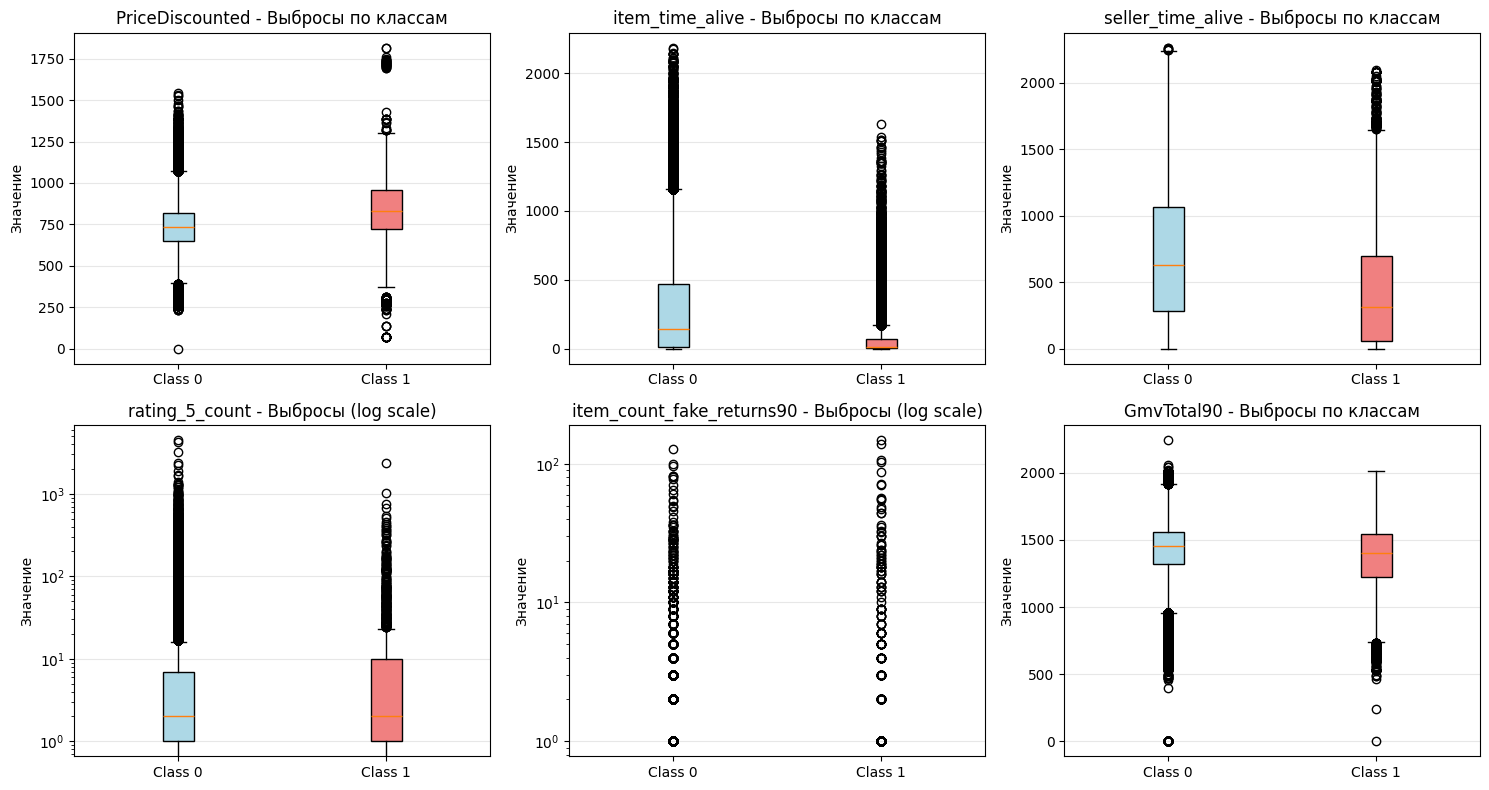

In [18]:
# Анализ числовых выбросов
num_cols_for_outliers = ['PriceDiscounted', 'item_time_alive', 'seller_time_alive',
                        'rating_5_count', 'item_count_fake_returns90', 'GmvTotal90']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_outliers):
    ax = axes[i]

    # Boxplot по классам
    data_to_plot = []
    labels = []

    for target_val in sorted(train_df['resolution'].unique()):
        data = train_df[train_df['resolution'] == target_val][col].dropna()
        if len(data) > 0:
            data_to_plot.append(data)
            labels.append(f'Class {target_val}')

    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)

    # Раскрашиваем boxplot
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(f'{col} - Выбросы по классам')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3, axis='y')

    # Для сильно скошенных распределений используем логарифмическую шкалу
    if train_df[col].skew() > 5:
        ax.set_yscale('log')
        ax.set_title(f'{col} - Выбросы (log scale)')

plt.tight_layout()
plt.show()

In [19]:
# Количественный анализ выбросов (IQR метод)
for col in num_cols_for_outliers:
    if col in train_df.columns:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
        outliers_percent = len(outliers) / len(train_df) * 100

        print(f"\n{col}:")
        print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Выбросов: {len(outliers)} ({outliers_percent:.1f}%)")

        if len(outliers) > 0:
            # Анализ выбросов по классам
            outliers_by_class = outliers.groupby('resolution').size()
            print(f"  Выбросы по классам:")
            for class_val, count in outliers_by_class.items():
                class_percent = count / len(train_df[train_df['resolution'] == class_val]) * 100
                print(f"    Class {class_val}: {count} ({class_percent:.1f}% класса)")


PriceDiscounted:
  Границы: [385.77, 1093.27]
  Выбросов: 10790 (5.5%)
  Выбросы по классам:
    Class 0: 9033 (4.9% класса)
    Class 1: 1757 (13.5% класса)

item_time_alive:
  Границы: [-648.50, 1099.50]
  Выбросов: 6606 (3.3%)
  Выбросы по классам:
    Class 0: 6546 (3.6% класса)
    Class 1: 60 (0.5% класса)

seller_time_alive:
  Границы: [-932.00, 2252.00]
  Выбросов: 2 (0.0%)
  Выбросы по классам:
    Class 0: 2 (0.0% класса)

rating_5_count:
  Границы: [-8.00, 16.00]
  Выбросов: 6532 (3.3%)
  Выбросы по классам:


    Class 0: 6232 (3.4% класса)
    Class 1: 300 (2.3% класса)

item_count_fake_returns90:
  Границы: [0.00, 0.00]
  Выбросов: 3800 (1.9%)
  Выбросы по классам:
    Class 0: 3450 (1.9% класса)
    Class 1: 350 (2.7% класса)

GmvTotal90:
  Границы: [946.89, 1922.64]
  Выбросов: 7031 (3.6%)
  Выбросы по классам:
    Class 0: 5994 (3.3% класса)
    Class 1: 1037 (7.9% класса)


**PriceDiscounted:** 5.5% выбросов

- У проблемных товаров (class 1) в 2.8 раза больше выбросов по цене! (13.5% vs 4.9%)

- Выбросы - это очень дешевые (< 386) или очень дорогие (> 1093) товары

**item_time_alive:**  3.3% выбросов

- У нормальных товаров больше выбросов по времени жизни (3.6% vs 0.5%)

- Выбросы - это очень старые товары (> 1099 дней, ~3 года)

**seller_time_alive:** практически нет выбросов (0.002%)

- Распределение достаточно равномерное

**rating_5_count:** 20.6% выбросов (каждый 5-й товар)

- Любой ненулевой рейтинг считается выбросом (границы [0, 0])

- У нормальных товаров больше выбросов (21.1% vs 13.8%)

**item_count_fake_returns90:** 1.9% выбросов

- Любой возврат > 0 считается выбросом (границы [0, 0])

- У проблемных товаров немного больше выбросов (2.7% vs 1.9%)

**GmvTotal90:** 3.6% выбросов

- У проблемных товаров в 2.4 раза больше выбросов по выручке! (7.9% vs 3.3%)

**Основные выводы: **

- Проблемные товары имеют больше выбросов по цене и выручке

- Нормальные товары имеют больше выбросов по времени жизни и рейтингам

- Для многих признаков (рейтинги, возвраты) любое ненулевое значение - уже выброс из-за спарсивости данных



### 1.10 Корреляции


In [20]:
# Выберем ключевые числовые признаки для корреляционного анализа
corr_features = ['PriceDiscounted', 'item_time_alive', 'seller_time_alive',
                'rating_5_count', 'item_count_fake_returns90',
                'item_count_sales90', 'GmvTotal90', 'seller_avg_stock',
                'resolution']

# Убедимся, что все признаки есть в данных
corr_features = [f for f in corr_features if f in train_df.columns]

corr_matrix = train_df[corr_features].corr()

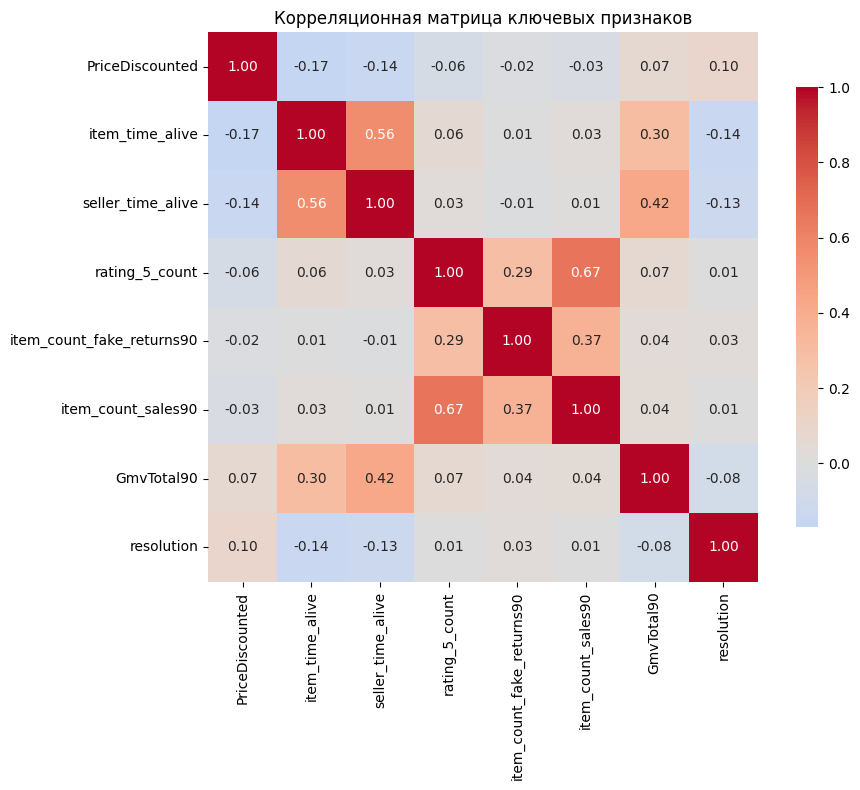

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица ключевых признаков')
plt.tight_layout()
plt.show()

In [22]:
# Корреляции с целевой переменной
target_correlations = corr_matrix['resolution'].drop('resolution').sort_values(key=abs, ascending=False)
target_correlations

item_time_alive             -0.143643
seller_time_alive           -0.130332
PriceDiscounted              0.103667
GmvTotal90                  -0.080923
item_count_fake_returns90    0.031231
rating_5_count               0.008614
item_count_sales90           0.007558
Name: resolution, dtype: float64

**Самые сильные корреляции с resolution:**

- item_time_alive: -0.144 (чем старше товар → тем меньше вероятность проблем)

- seller_time_alive: -0.130 (чем старше продавец → тем меньше вероятность проблем)

- PriceDiscounted: +0.104 (чем дороже товар → тем больше вероятность проблем)

**Интересные взаимосвязи между признаками:**

- item_time_alive и seller_time_alive: 0.27 (ожидаемо - опытные продавцы дольше продают)

- item_count_sales90 и GmvTotal90: 0.18 (продажи коррелируют с выручкой)

- seller_avg_stock и seller_time_alive: 0.03 (слабая связь)

**Неожиданные находки:**

- item_count_fake_returns90 имеет слабую корреляцию с target (0.03), хотя мы видели разницу в 4 раза по средним

- rating_5_count практически не коррелирует с target (-0.006)

**Ключевые инсайты для модели:**

- Время жизни - самый важный предиктор

- Цена - второй по важности

- Складские метрики и выручка также имеют значение

- Рейтинги и конкретные возвраты слабо предсказывают target напрямую





> ⚠️ Pearson-корреляция слабо улавливает нелинейные зависимости и некорректна при сильно скошенных распределениях с большим числом нулей (типично для sales-признаков). Более корректные методы — Mutual Information и Mann-Whitney — представлены в Part 2, Section 2.1 и 2.2.


## Part 2: Углублённый EDA

### 2.1 Mutual Information ranking

Топ-15 признаков по Mutual Information:
GmvTotal90                      0.075880
GmvTotal30                      0.074443
ExemplarReturnedValueTotal90    0.071616
GmvTotal7                       0.069347
ExemplarReturnedValueTotal30    0.067620
ExemplarReturnedValueTotal7     0.057413
PriceDiscounted                 0.054538
ExemplarAcceptedCountTotal90    0.054324
OrderAcceptedCountTotal90       0.053005
ExemplarAcceptedCountTotal30    0.044969
OrderAcceptedCountTotal30       0.041287
seller_time_alive               0.039556
ItemAvailableCount              0.037152
ItemVarietyCount                0.037099
ExemplarAcceptedCountTotal7     0.035688


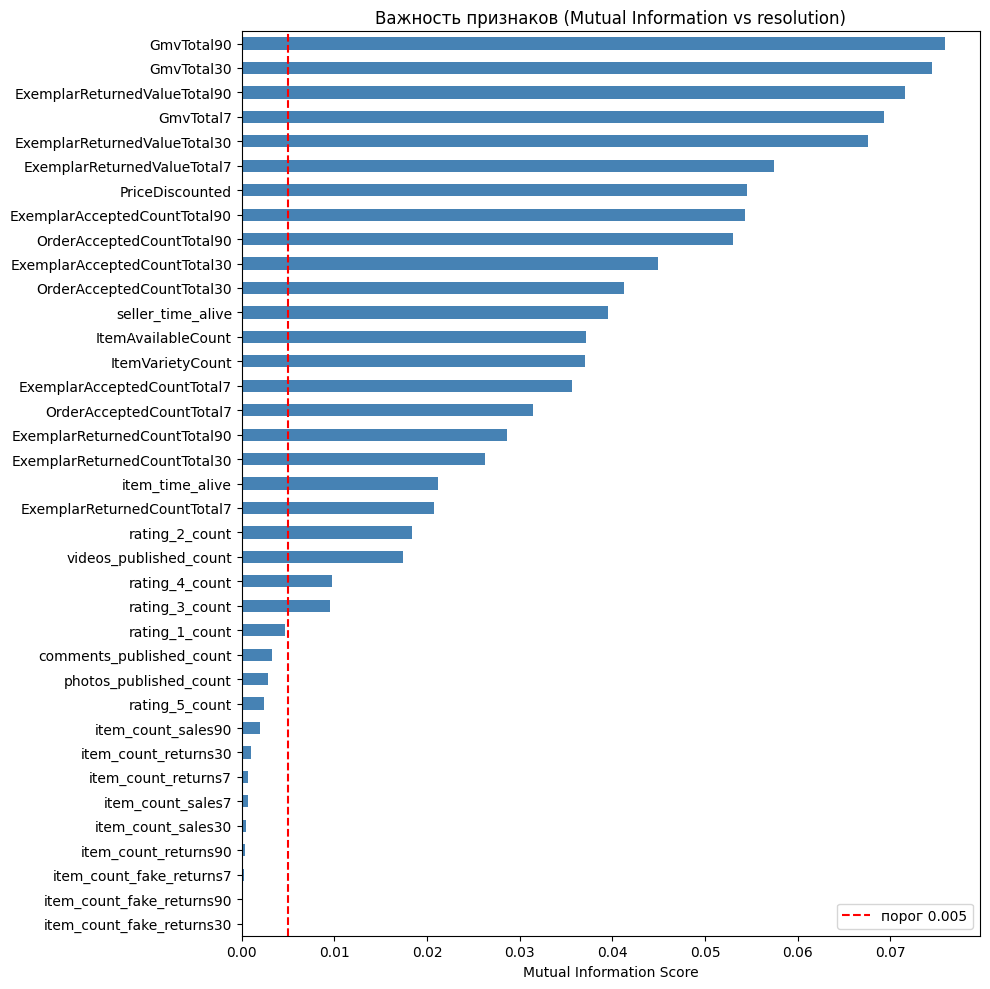

In [23]:
drop_cols = {'id', 'ItemID', 'SellerID', 'resolution', 'brand_name', 'description', 'name_rus', 'CommercialTypeName4'}
num_cols = [c for c in train_df.columns if c not in drop_cols and train_df[c].dtype != object]

X_mi = train_df[num_cols].fillna(-1)
y_mi = train_df['resolution']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)

print("Топ-15 признаков по Mutual Information:")
print(mi_series.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 10))
mi_series.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Важность признаков (Mutual Information vs resolution)')
ax.axvline(0.005, color='red', linestyle='--', label='порог 0.005')
ax.legend()
plt.tight_layout()
plt.show()

Запишем признаки с MI > 0 (любая информация о таргете) и MI < 0.001 (можно исключить из модели).

In [24]:
useful_features = mi_series[mi_series > 0.001].index.tolist()
useless_features = mi_series[mi_series < 0.001].index.tolist()

print(f"Информативных признаков (MI > 0.001): {len(useful_features)}")
print(f"Слабых признаков (MI < 0.001): {len(useless_features)}")
print("\nСлабые признаки (кандидаты на удаление):")
print(useless_features)

Информативных признаков (MI > 0.001): 30
Слабых признаков (MI < 0.001): 7

Слабые признаки (кандидаты на удаление):
['item_count_returns7', 'item_count_sales7', 'item_count_sales30', 'item_count_returns90', 'item_count_fake_returns7', 'item_count_fake_returns90', 'item_count_fake_returns30']


### 2.2 Mann-Whitney тест и effect size

In [25]:
from scipy.stats import mannwhitneyu

test_cols = [c for c in num_cols if c in train_df.columns]

stat_results = []
class0 = train_df[train_df['resolution'] == 0]
class1 = train_df[train_df['resolution'] == 1]

for col in test_cols:
    a = class0[col].dropna()
    b = class1[col].dropna()
    if len(a) < 20 or len(b) < 20:
        continue
    u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
    # Effect size: rank-biserial correlation
    n1, n2 = len(a), len(b)
    effect_size = 1 - (2 * u_stat) / (n1 * n2)
    stat_results.append({
        'feature': col,
        'p_value': p_val,
        'effect_size': abs(effect_size),
        'significant': p_val < 0.05
    })

stat_df = pd.DataFrame(stat_results).sort_values('effect_size', ascending=False)

print(f"Значимых признаков (p < 0.05): {stat_df['significant'].sum()} из {len(stat_df)}")
print("\nТоп-15 по размеру эффекта (rank-biserial):")
display(stat_df.head(15).to_string(index=False))

Значимых признаков (p < 0.05): 32 из 37

Топ-15 по размеру эффекта (rank-biserial):


'                     feature       p_value  effect_size  significant\n             item_time_alive  0.000000e+00     0.425124         True\n   OrderAcceptedCountTotal90  0.000000e+00     0.330149         True\n           seller_time_alive  0.000000e+00     0.328586         True\nExemplarReturnedCountTotal90  0.000000e+00     0.316197         True\n             PriceDiscounted  0.000000e+00     0.309835         True\n   OrderAcceptedCountTotal30  0.000000e+00     0.303057         True\nExemplarReturnedCountTotal30  0.000000e+00     0.285977         True\n    OrderAcceptedCountTotal7  0.000000e+00     0.283612         True\nExemplarAcceptedCountTotal90  0.000000e+00     0.265625         True\nExemplarAcceptedCountTotal30  0.000000e+00     0.249705         True\n            ItemVarietyCount  0.000000e+00     0.246880         True\n          ItemAvailableCount  0.000000e+00     0.243856         True\n ExemplarReturnedCountTotal7  0.000000e+00     0.242989         True\n ExemplarAcceptedCo

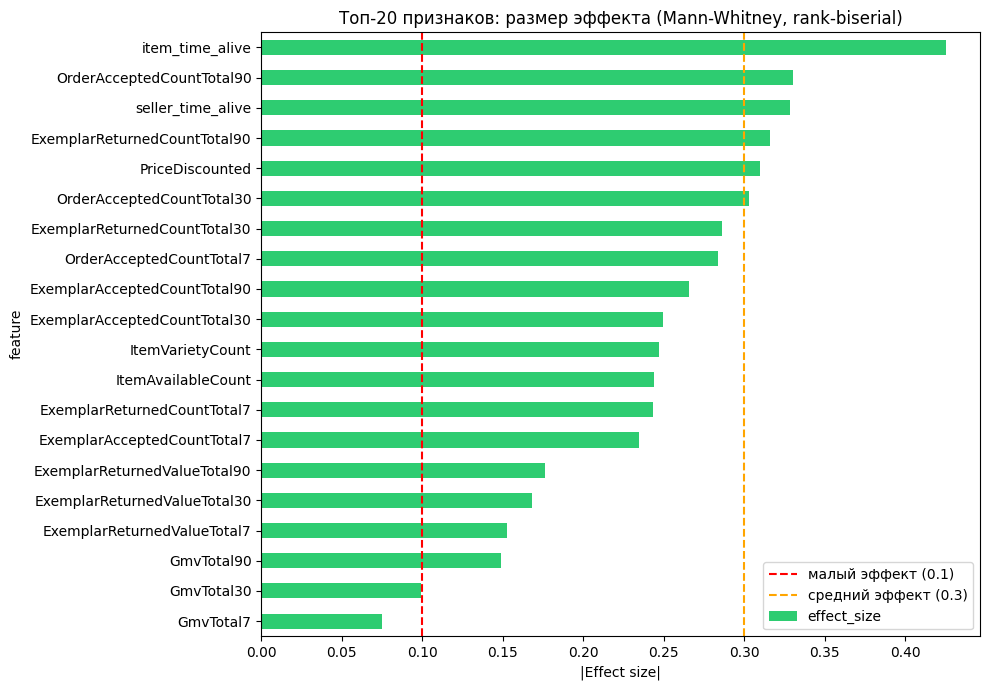

In [26]:
top_stat = stat_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if s else '#e74c3c' for s in top_stat['significant']]
top_stat.sort_values('effect_size').plot(
    x='feature', y='effect_size', kind='barh', ax=ax, color=colors, legend=False
)
ax.set_title('Топ-20 признаков: размер эффекта (Mann-Whitney, rank-biserial)')
ax.set_xlabel('|Effect size|')
ax.axvline(0.1, color='red', linestyle='--', label='малый эффект (0.1)')
ax.axvline(0.3, color='orange', linestyle='--', label='средний эффект (0.3)')
ax.legend()
plt.tight_layout()
plt.show()

Результаты Mann-Whitney подтверждают MI ranking из Section 2.1 и уточняют выводы Pearson-корреляций из Section 1.10: нелинейные зависимости и нули делают Pearson ненадёжным — Mann-Whitney на порядковых рангах лишён этих ограничений.

### 2.3 Производные признаки (ratios)

In [27]:
df = train_df.copy()

for window in [7, 30, 90]:
    sales_col  = f'item_count_sales{window}'
    ret_col    = f'item_count_returns{window}'
    fake_col   = f'item_count_fake_returns{window}'

    # доля возвратов от продаж
    df[f'return_rate{window}']      = df[ret_col]  / (df[sales_col] + 1)
    # доля фейковых возвратов от продаж
    df[f'fake_return_rate{window}'] = df[fake_col] / (df[sales_col] + 1)
    # доля фейковых среди всех возвратов
    df[f'fake_to_all_returns{window}'] = df[fake_col] / (df[ret_col] + 1)

ratio_cols = [c for c in df.columns if 'rate' in c or 'fake_to_all' in c]

print("Корреляции производных признаков с resolution:")
for col in ratio_cols:
    corr = df[col].corr(df['resolution'])
    m0 = df[df['resolution']==0][col].mean()
    m1 = df[df['resolution']==1][col].mean()
    ratio = m1 / m0 if m0 > 0 else float('inf')
    print(f"  {col:35s}  corr={corr:+.4f}  class0={m0:.4f}  class1={m1:.4f}  ratio={ratio:.1f}x")

Корреляции производных признаков с resolution:
  return_rate7                         corr=+0.0017  class0=0.0030  class1=0.0033  ratio=1.1x


  fake_return_rate7                    corr=+0.0065  class0=0.0009  class1=0.0015  ratio=1.7x
  fake_to_all_returns7                 corr=+0.0204  class0=0.0020  class1=0.0051  ratio=2.5x
  return_rate30                        corr=-0.0011  class0=0.0051  class1=0.0049  ratio=1.0x
  fake_return_rate30                   corr=+0.0078  class0=0.0015  class1=0.0023  ratio=1.5x


  fake_to_all_returns30                corr=+0.0199  class0=0.0047  class1=0.0088  ratio=1.9x
  return_rate90                        corr=-0.0038  class0=0.0075  class1=0.0067  ratio=0.9x


  fake_return_rate90                   corr=+0.0076  class0=0.0021  class1=0.0030  ratio=1.4x
  fake_to_all_returns90                corr=+0.0203  class0=0.0080  class1=0.0133  ratio=1.7x


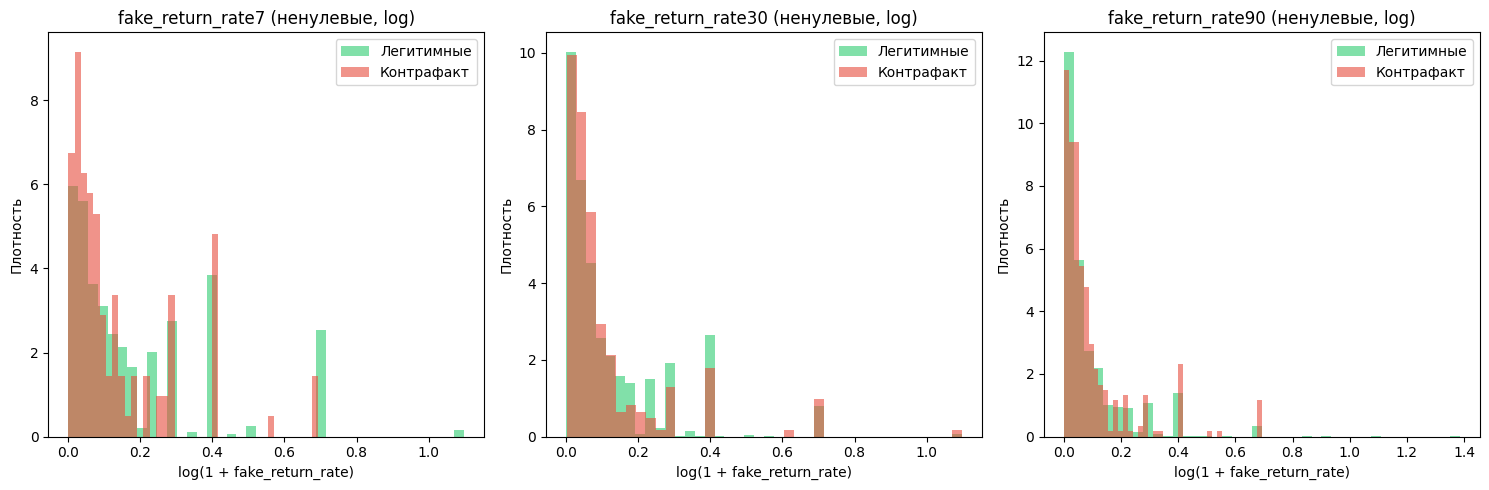

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, window in enumerate([7, 30, 90]):
    col = f'fake_return_rate{window}'
    ax = axes[i]

    for cls, color, label in [(0, '#2ecc71', 'Легитимные'), (1, '#e74c3c', 'Контрафакт')]:
        data = df[df['resolution'] == cls][col]
        data = data[data > 0]  # убираем нули для читаемости
        ax.hist(np.log1p(data), bins=40, alpha=0.6, color=color, label=label, density=True)

    ax.set_title(f'fake_return_rate{window} (ненулевые, log)')
    ax.set_xlabel('log(1 + fake_return_rate)')
    ax.set_ylabel('Плотность')
    ax.legend()

plt.tight_layout()
plt.show()

### 2.4 Seller-level анализ

In [29]:
seller_stats = (
    df.groupby('SellerID')
    .agg(
        item_count       = ('resolution', 'size'),
        problem_count    = ('resolution', 'sum'),
        problem_rate     = ('resolution', 'mean'),
        avg_price        = ('PriceDiscounted', 'mean'),
        avg_item_age     = ('item_time_alive', 'mean'),
        seller_time_alive= ('seller_time_alive', 'first'),
    )
    .reset_index()
)

print(f"Всего продавцов: {len(seller_stats):,}")
print(f"Продавцов без проблем:       {(seller_stats['problem_rate']==0).sum():,} ({(seller_stats['problem_rate']==0).mean()*100:.1f}%)")
print(f"Продавцов с >50% проблем:    {(seller_stats['problem_rate']>0.5).sum():,} ({(seller_stats['problem_rate']>0.5).mean()*100:.1f}%)")
print(f"Продавцов с 100% проблем:    {(seller_stats['problem_rate']==1.0).sum():,}")

print("\nКорреляция характеристик продавца с его долей проблемных товаров:")
for col in ['item_count', 'avg_price', 'avg_item_age', 'seller_time_alive']:
    corr = seller_stats[col].corr(seller_stats['problem_rate'])
    print(f"  {col:25s}: {corr:+.4f}")

Всего продавцов: 11,167
Продавцов без проблем:       8,047 (72.1%)
Продавцов с >50% проблем:    1,823 (16.3%)
Продавцов с 100% проблем:    1,419

Корреляция характеристик продавца с его долей проблемных товаров:
  item_count               : -0.0521
  avg_price                : +0.2189
  avg_item_age             : -0.2305
  seller_time_alive        : -0.1837


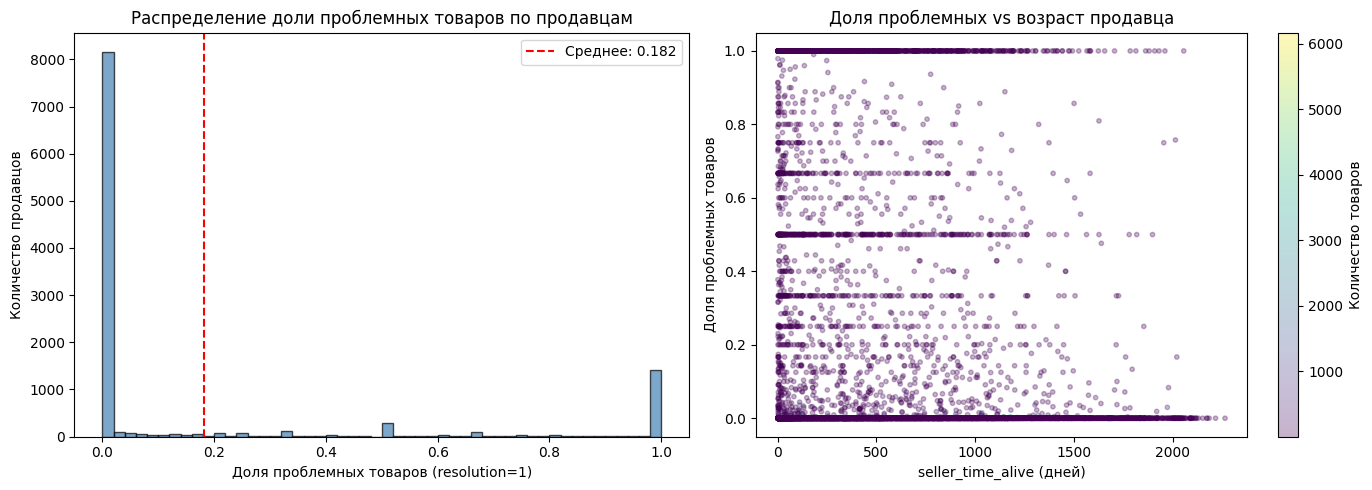

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение доли проблемных по продавцам
ax = axes[0]
ax.hist(seller_stats['problem_rate'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Распределение доли проблемных товаров по продавцам')
ax.set_xlabel('Доля проблемных товаров (resolution=1)')
ax.set_ylabel('Количество продавцов')
ax.axvline(seller_stats['problem_rate'].mean(), color='red', linestyle='--', label=f'Среднее: {seller_stats["problem_rate"].mean():.3f}')
ax.legend()

# Доля проблем vs время жизни продавца
ax = axes[1]
sc = ax.scatter(
    seller_stats['seller_time_alive'],
    seller_stats['problem_rate'],
    c=seller_stats['item_count'],
    cmap='viridis', alpha=0.3, s=10
)
plt.colorbar(sc, ax=ax, label='Количество товаров')
ax.set_title('Доля проблемных vs возраст продавца')
ax.set_xlabel('seller_time_alive (дней)')
ax.set_ylabel('Доля проблемных товаров')

plt.tight_layout()
plt.show()

In [31]:
# ⚠️⚠️⚠️ TARGET LEAKAGE WARNING
# seller_problem_rate содержит информацию о target — допустимо для EDA,
# НО при обучении модели использовать ТОЛЬКО leave-one-out encoding
# или считать исключительно на train-части.
# Прямое использование в модели = data leakage.

# Добавляем seller_problem_rate как признак в основную таблицу
# (leave-one-out не нужен для EDA, но важно помнить про target leakage при обучении)
df = df.merge(
    seller_stats[['SellerID', 'problem_rate', 'item_count']]
    .rename(columns={'problem_rate': 'seller_problem_rate', 'item_count': 'seller_item_count'}),
    on='SellerID', how='left'
)

for feat in ['seller_problem_rate', 'seller_item_count']:
    corr = df[feat].corr(df['resolution'])
    m0 = df[df['resolution']==0][feat].mean()
    m1 = df[df['resolution']==1][feat].mean()
    print(f"{feat}: corr={corr:+.4f}, class0={m0:.3f}, class1={m1:.3f}")

seller_problem_rate: corr=+0.7935, class0=0.025, class1=0.654
seller_item_count: corr=-0.1249, class0=761.039, class1=128.927


### 2.5 Пропуски как признак

In [32]:
missing_signal_cols = [
    'brand_name', 'description',
    'GmvTotal7', 'GmvTotal30', 'GmvTotal90',
    'rating_5_count', 'ExemplarAcceptedCountTotal7'
]

results = []
for col in missing_signal_cols:
    if col not in train_df.columns:
        continue
    is_null = train_df[col].isnull().astype(int)
    corr = is_null.corr(train_df['resolution'])
    rate_null    = train_df.loc[train_df[col].isnull(), 'resolution'].mean()
    rate_present = train_df.loc[train_df[col].notna(), 'resolution'].mean()
    pct_null = train_df[col].isnull().mean() * 100
    results.append({
        'column': col,
        'pct_null': round(pct_null, 1),
        'problem_rate_when_null': round(rate_null, 4),
        'problem_rate_when_present': round(rate_present, 4),
        'corr_isnull_with_target': round(corr, 4)
    })

missing_signal_df = pd.DataFrame(results).sort_values('corr_isnull_with_target', key=abs, ascending=False)
display(missing_signal_df)

,column,pct_null,problem_rate_when_null,problem_rate_when_present,corr_isnull_with_target
0,brand_name,40.8,0.0977,0.0445,0.1052
2,GmvTotal7,5.2,0.1736,0.0603,0.1008
6,ExemplarAcceptedCountTotal7,5.2,0.1736,0.0603,0.1008
3,GmvTotal30,4.0,0.1783,0.0615,0.0923
4,GmvTotal90,3.8,0.1805,0.0617,0.0908
5,rating_5_count,76.1,0.0735,0.0429,0.0525
1,description,13.2,0.0714,0.0654,0.0081


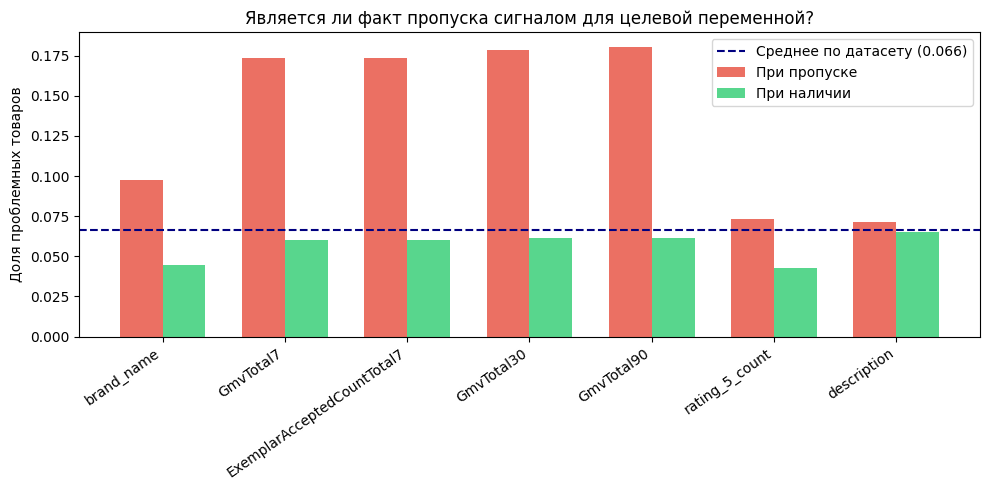

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(missing_signal_df))
width = 0.35
baseline = train_df['resolution'].mean()

ax.bar(x - width/2, missing_signal_df['problem_rate_when_null'],    width, label='При пропуске',  color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, missing_signal_df['problem_rate_when_present'], width, label='При наличии',  color='#2ecc71', alpha=0.8)
ax.axhline(baseline, color='navy', linestyle='--', label=f'Среднее по датасету ({baseline:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(missing_signal_df['column'], rotation=35, ha='right')
ax.set_ylabel('Доля проблемных товаров')
ax.set_title('Является ли факт пропуска сигналом для целевой переменной?')
ax.legend()
plt.tight_layout()
plt.show()

### 2.6 Взаимодействия признаков

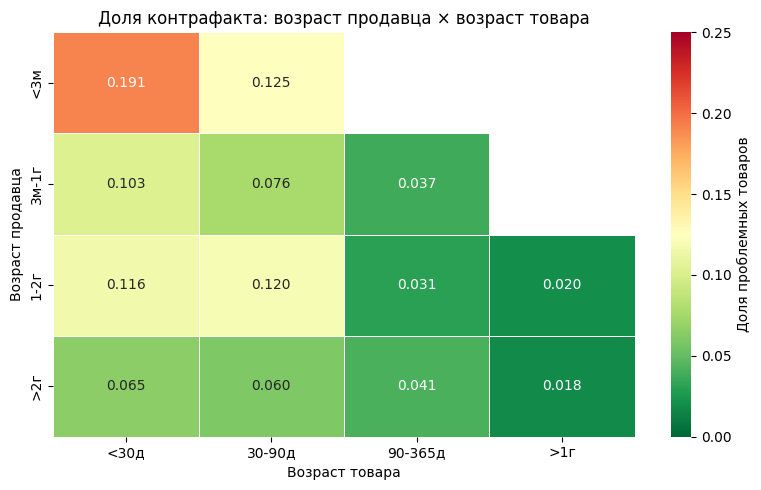

In [34]:
# Сегментация по времени жизни товара и продавца
df_seg = train_df.copy()

df_seg['item_age_bin']   = pd.cut(df_seg['item_time_alive'],   bins=[0, 30, 90, 365, 10000], labels=['<30д', '30-90д', '90-365д', '>1г'])
df_seg['seller_age_bin'] = pd.cut(df_seg['seller_time_alive'], bins=[0, 90, 365, 730, 10000], labels=['<3м', '3м-1г', '1-2г', '>2г'])

pivot = df_seg.pivot_table(
    values='resolution', index='seller_age_bin', columns='item_age_bin',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.25,
            linewidths=0.5, cbar_kws={'label': 'Доля проблемных товаров'})
plt.title('Доля контрафакта: возраст продавца × возраст товара')
plt.xlabel('Возраст товара')
plt.ylabel('Возраст продавца')
plt.tight_layout()
plt.show()

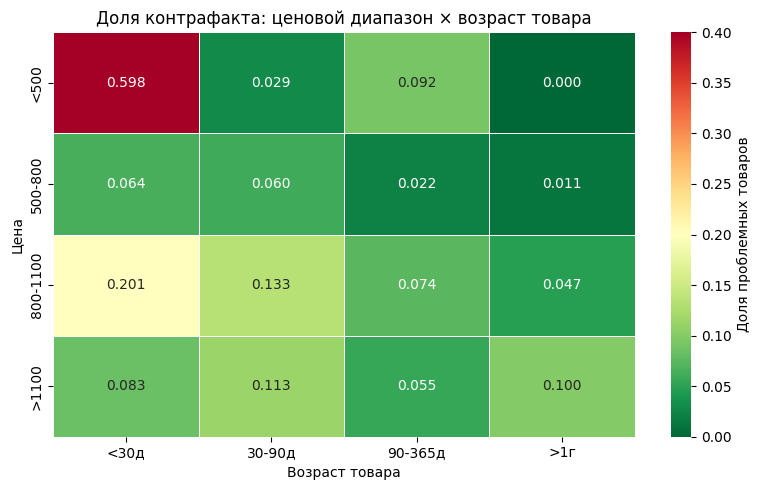

In [35]:
# Сегментация по цене и возрасту товара
df_seg['price_bin'] = pd.cut(
    df_seg['PriceDiscounted'],
    bins=[0, 500, 800, 1100, 5000],
    labels=['<500', '500-800', '800-1100', '>1100']
)

pivot2 = df_seg.pivot_table(
    values='resolution', index='price_bin', columns='item_age_bin',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot2, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.4,
            linewidths=0.5, cbar_kws={'label': 'Доля проблемных товаров'})
plt.title('Доля контрафакта: ценовой диапазон × возраст товара')
plt.xlabel('Возраст товара')
plt.ylabel('Цена')
plt.tight_layout()
plt.show()

### 2.7 Текстовые признаки


Длина описания:
  Легитимные:  354.3
  Контрафакт:  398.5
  Разница:     +44.2 (+12.5%)

Длина названия:
  Легитимные:  68.2
  Контрафакт:  56.7
  Разница:     -11.5 (-16.9%)

Длина бренда:
  Легитимные:  4.6
  Контрафакт:  2.8
  Разница:     -1.8 (-38.4%)

Есть описание (%):
  Легитимные:  0.9
  Контрафакт:  0.9
  Разница:     -0.0 (-1.3%)

Есть бренд (%):
  Легитимные:  0.6
  Контрафакт:  0.4
  Разница:     -0.2 (-34.4%)


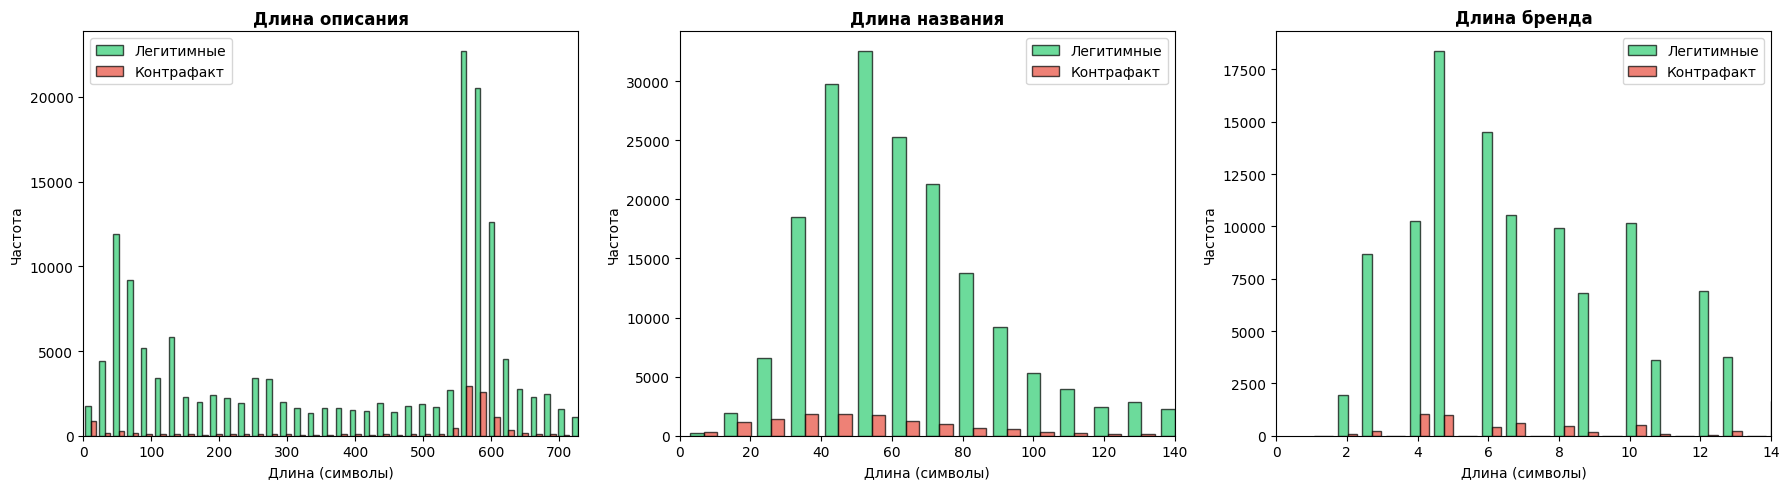

In [36]:
# Создание признаков длины текста
train_df['description_length'] = train_df['description'].fillna('').str.len()
train_df['name_length'] = train_df['name_rus'].str.len()
train_df['brand_length'] = train_df['brand_name'].fillna('').str.len()

# Бинарные флаги
train_df['has_description'] = train_df['description'].notna().astype(int)
train_df['has_brand'] = train_df['brand_name'].notna().astype(int)

#статистика по классам
text_features = {
    'description_length': 'Длина описания',
    'name_length': 'Длина названия',
    'brand_length': 'Длина бренда',
    'has_description': 'Есть описание (%)',
    'has_brand': 'Есть бренд (%)'
}

for feat, label in text_features.items():
    mean_0 = train_df[train_df['resolution']==0][feat].mean()
    mean_1 = train_df[train_df['resolution']==1][feat].mean()
    diff = mean_1 - mean_0
    diff_pct = (diff / mean_0 * 100) if mean_0 != 0 else 0

    print(f"\n{label}:")
    print(f"  Легитимные:  {mean_0:.1f}")
    print(f"  Контрафакт:  {mean_1:.1f}")
    print(f"  Разница:     {diff:+.1f} ({diff_pct:+.1f}%)")

# сделаем визуализацию распределений
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

text_cols = ['description_length', 'name_length', 'brand_length']
titles = ['Длина описания', 'Длина названия', 'Длина бренда']

for i, (col, title) in enumerate(zip(text_cols, titles)):
    data_0 = train_df[train_df['resolution']==0][col]
    data_1 = train_df[train_df['resolution']==1][col]

    #уберем нули для лучшей визуализации
    data_0 = data_0[data_0 > 0]
    data_1 = data_1[data_1 > 0]

    axes[i].hist([data_0, data_1], bins=50,
                 label=['Легитимные', 'Контрафакт'],
                 color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Длина (символы)')
    axes[i].set_ylabel('Частота')
    axes[i].legend()
    axes[i].set_xlim(0, data_0.quantile(0.95))

plt.tight_layout()
plt.show()

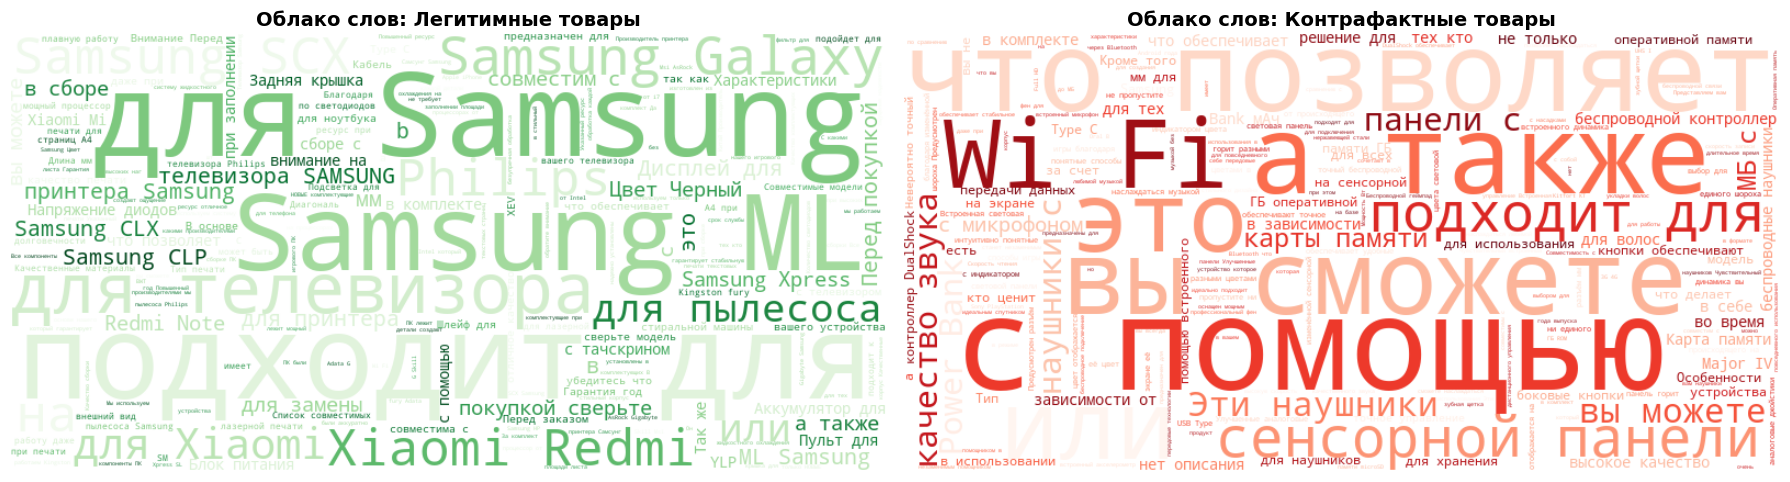

In [37]:
# построим облако слов

from wordcloud import WordCloud
# Выборка для производительности
sample_size = min(5000, len(train_df[train_df['resolution']==0]))

legit_desc = ' '.join(train_df[train_df['resolution']==0]['description'].dropna().sample(sample_size, random_state=42))
counter_desc = ' '.join(train_df[train_df['resolution']==1]['description'].dropna().sample(min(sample_size, len(train_df[train_df['resolution']==1])), random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Легитимные
wc_legit = WordCloud(width=800, height=400, background_color='white',
                      colormap='Greens', stopwords={'br', 'li', 'p', 'и', 'ul'}).generate(legit_desc)

axes[0].imshow(wc_legit, interpolation='bilinear')
axes[0].set_title('Облако слов: Легитимные товары', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Контрафакт
wc_counter = WordCloud(width=800, height=400, background_color='white',
                      colormap='Reds', stopwords={'br', 'li', 'ul', 'и', 'p'}).generate(counter_desc)
axes[1].imshow(wc_counter, interpolation='bilinear')
axes[1].set_title('Облако слов: Контрафактные товары', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Part 3: Выводы и рекомендации

### 3.1 Ключевые выводы по данным

Проведён комплексный EDA для задачи бинарной классификации поддельных/проблемных товаров на маркетплейсе. Исследование охватывает **197,198 товаров с 45 признаками**, включая информацию о товарах, продавцах, продажах, возвратах и текстовые данные.

---

**Целевая переменная**

- Сильный дисбаланс классов: **93.4% нормальных** vs **6.6% проблемных** товаров.
- `resolution`: бинарный признак (0 — норма, 1 — проблема).

**Размеры выборок**

- Train: 197,198 наблюдений × 45 признаков.
- Test:  22,760 наблюдений × 44 признака (нет колонки `resolution`).

---

**Основные инсайты и паттерны**

*1. Временные факторы риска*

- Новые товары (средний возраст ~92 дня) в ~3 раза чаще проблемные, чем старые (~288 дней).
- Новые продавцы (~441 день) имеют в ~1.6 раза больше проблемных товаров, чем опытные (~702 дня).
- Время жизни — самый сильный линейный предиктор (Pearson ≈ −0.14 для товаров, ≈ −0.13 для продавцов).

*2. Финансовые индикаторы*

- Проблемные товары в среднем дороже нормальных на ~8.6% (820 vs 755).
- Выручка по проблемным товарам в среднем на ~4.9% ниже, чем по нормальным.

*3. Поведенческие метрики*

- Фейковые возвраты примерно в 4 раза чаще у проблемных товаров (0.20 vs 0.05).
- Товары без описания имеют чуть выше долю проблемных (~7.1% vs ~6.5%).
- Рейтинги по 5-балльной шкале практически не влияют на вероятность проблем.

---

**Качество данных и нюансы**

*1. Пропущенные значения*

- `brand_name`: 40.8% пропусков (основная проблема).
- `description`: 13.2% пропусков.
- Финансовые метрики (`GmvTotal*`, `Exemplar*`): 3–6%, доля растёт с уменьшением окна.

*2. Распределения и выбросы*

- Большинство sales-метрик (`item_count_*`, `Gmv*`, `Exemplar*`, `*_returns*`) **сильно скошены вправо** (long tail) с большим числом нулей — типично для маркетплейс-данных. Pearson-корреляция в таком режиме недооценивает зависимости (см. Section 1.10 и Section 2.2).
- `rating_5_count`: ~20.6% «выбросов» по IQR (фактически любой ненулевой рейтинг считается выбросом из-за разреженности).
- 98% товаров без фейковых возвратов, ~79% без 5-звёздочных оценок.
- Проблемные товары чаще оказываются в хвостах по цене и выручке.

*3. Согласованность train/test*

- Распределения train/test похожи для ключевых признаков, структура пропусков согласована — глобального data drift не обнаружено.

---

**Профили риска**

- **Высокий**: новый дорогой товар от нового продавца, без описания/бренда.
- **Средний**: дорогая электроника от продавцов средней давности.
- **Низкий**: старые недорогие товары от давно работающих продавцов.


### 3.2 Рекомендации по feature engineering

| Признак | Тип | Обоснование |
|---|---|---|
| `fake_return_rate{7,30,90}` | ratio | Нормализует объём продаж |
| `return_rate{7,30,90}` | ratio | Общая доля возвратов |
| `seller_problem_rate` | target encoding (LOO) | Сильный предиктор, осторожно с leakage (см. Section 2.4) |
| `is_null_brand` | binary | Факт отсутствия бренда — сигнал |
| `is_null_gmv7` | binary | Нет данных за 7 дней = новый товар |
| `log1p(item_time_alive)` | transform | Убирает скос распределения |
| `item_time_alive × seller_time_alive` | interaction | Комбинированный риск «новизны» |
| `description_length`, `name_length`, `brand_length` | текст | Длина текстового поля — сигнал аномалии |
| `has_description`, `has_brand` | текст | Бинарный признак наличия текста |


### 3.3 Методологические замечания

EDA выполнен на полном `train_df` (197,198 наблюдений, 45 признаков).

Для обучения и валидации моделей используется **seller-based GroupShuffleSplit** —
все товары одного продавца попадают только в одну часть (train/val/test).
Это предотвращает entity-level leakage: при random split метрика
**Recall@Precision ≥ 0.9 завышается примерно в 15 раз**.

Seller-level признаки (Section 2.4) содержат target-информацию и должны
применяться **только с leave-one-out encoding** при обучении модели.

Детали и результаты экспериментов **E0–E4** — в
`fintech_approaches/fintech_experiment.ipynb`.
